# Selección y Filtrado de Ratings

En este notebook realizamos la limpieza, selección y filtrado de los ratings que los usuarios de MovieLens asignaron a las películas.

El objetivo es obtener un conjunto de ratings de calidad que sea:
- **Denso:** suficientes interacciones por usuario para aprender sus preferencias
- **Diverso:** usuarios que consuman distintos géneros y usen distintas calificaciones
- **Manejable:** alrededor de **1,000,000 ratings** de **10,000 usuarios** sobre las 5,000 películas seleccionadas

Este dataset es el insumo principal para los modelos de filtrado colaborativo y para la extracción de personalidad.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from random import sample

Cargamos el dataset completo de ratings de MovieLens (`ratings.parquet`).

In [2]:
ratings = pd.read_parquet('../data/raw/ratings.parquet')
ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [3]:
print(f'The dataset has {ratings.shape[0]:,} ratings from {len(ratings['userId'].unique()):,} users')

The dataset has 32,000,204 ratings from 200,948 users


In [4]:
# Check if there are decimal values
decimals = ratings[ratings['rating'] % 1 != 0].shape[0]
print(f'There are {decimals:,} ratigns with .5 values')

There are 10,005,686 ratigns with .5 values


## Distribución de Ratings (1-5)

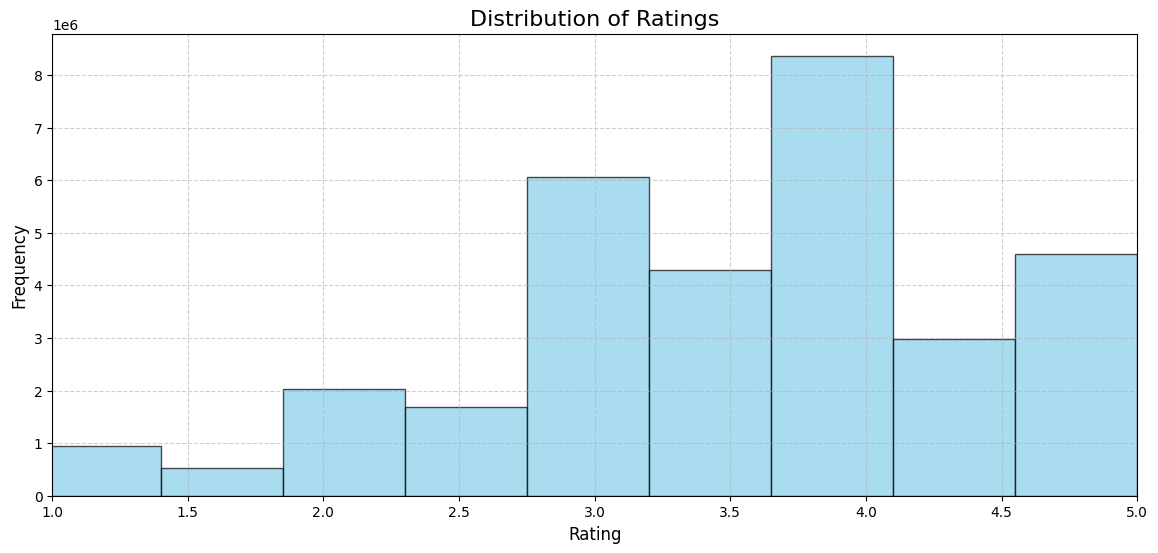

In [5]:
plt.figure(figsize=(14, 6))
#Since the ratings range from 1 to 5, with the possibility of half-point increments, we will use 10 bins
plt.hist(ratings['rating'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(1, 5)
plt.show()

Observaciones sobre la distribución de ratings:

- El rating más frecuente es **4.0**, seguido de 3.0
- El rating menos usado es 1.5
- Existe un sesgo hacia ratings de 3 o superior: la mayoría de los votos son positivos
- Los usuarios prefieren ratings enteros sobre los de .5 (p. ej., 4.0 >> 3.5)

### Distribución Temporal de Ratings

In [6]:
# Convert the timestamp format
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')

# Extract the year
ratings['year'] = ratings['date'].dt.year
ratings.head()

,userId,movieId,rating,timestamp,date,year
0,1,17,4.0,944249077,1999-12-03 19:24:37,1999
1,1,25,1.0,944250228,1999-12-03 19:43:48,1999
2,1,29,2.0,943230976,1999-11-22 00:36:16,1999
3,1,30,5.0,944249077,1999-12-03 19:24:37,1999
4,1,32,5.0,943228858,1999-11-22 00:00:58,1999


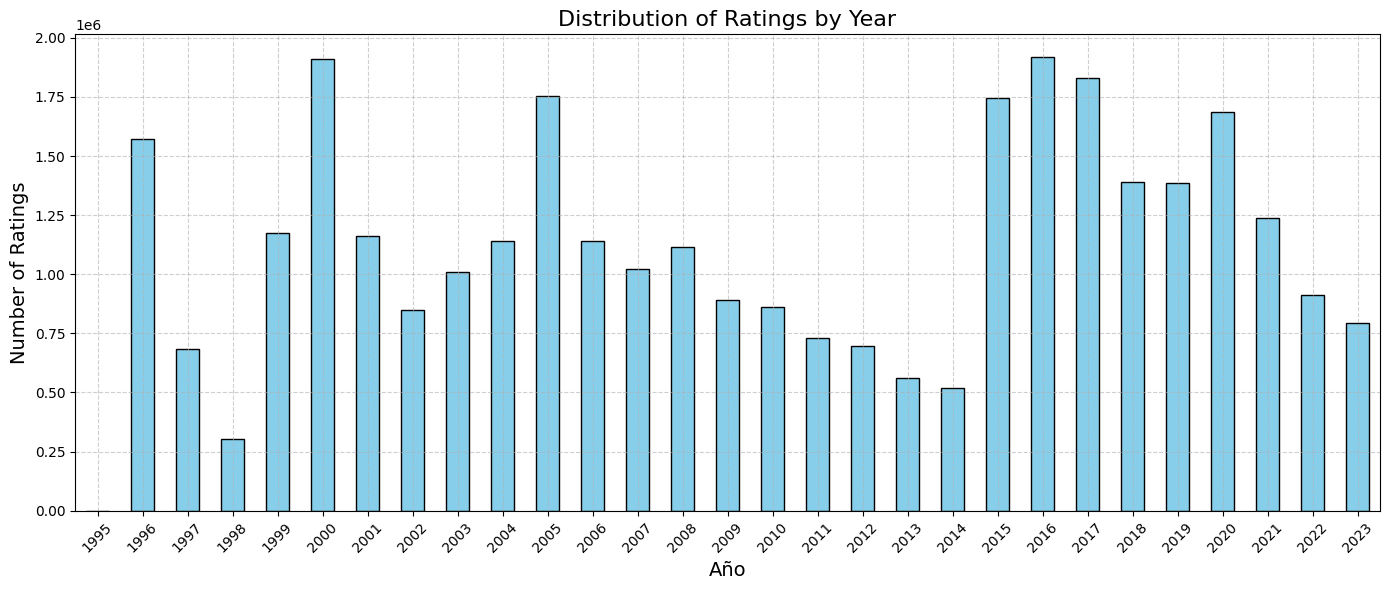

In [7]:
# Plot the distribution frequency of ratigns per year
ratings_by_year = ratings.groupby('year').size()
plt.figure(figsize=(14, 6))
ratings_by_year.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Distribution of Ratings by Year', fontsize=16)
plt.xlabel('Año', fontsize=14)
plt.ylabel('Number of Ratings', fontsize=14)

# Improve ticks
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Show it
plt.tight_layout()
plt.show()

Observaciones sobre la distribución temporal:

- Los años 2000, 2005, 2015 y 2016 destacan con un número muy alto de ratings
- Hay una caída notable entre 2008 y 2014
- A partir de 2014 hay un repunte significativo hasta 2016
- Filtraremos los ratings anteriores a 2006 para enfocarnos en el período más activo y relevante

## Conteo de Ratings por Usuario

El dataset original tiene una distribución muy sesgada: algunos usuarios tienen decenas de miles de ratings mientras que otros tienen solo 20. Para garantizar calidad en el sistema de recomendación y evitar la dispersión de datos, necesitamos filtrar los usuarios.

In [8]:
# Count the number of ratings per user
ratings_count = ratings.groupby('userId')['rating'].count()
ratings_count.head()

userId
1    141
2     52
3    147
4     27
5     33
Name: rating, dtype: int64

In [9]:
print(f'We have {ratings_count.shape[0]:,} users')

We have 200,948 users


In [10]:
ratings_count.describe()

count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
Name: rating, dtype: float64

La distribución muestra una alta variabilidad en la actividad de los usuarios. Existen **power users** con decenas de miles de ratings que pueden sesgar el entrenamiento de los modelos. El filtrado por rango de actividad nos permitirá equilibrar el dataset.

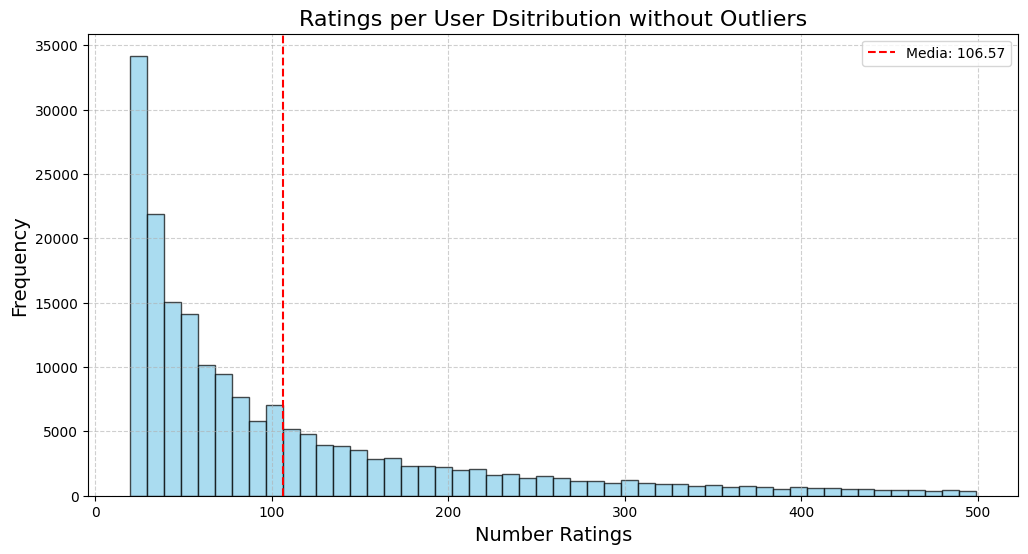

In [11]:
# Filter users with less than 500 ratings to improve the plot
ratings_filtered = ratings_count[ratings_count < 500]

# Create the plot
plt.figure(figsize=(12, 6))
plt.hist(ratings_filtered, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Plot the mean
plt.axvline(ratings_filtered.mean(), color='red', linestyle='--', label=f'Media: {ratings_filtered.mean():.2f}')

# Add labels and title
plt.title('Ratings per User Dsitribution without Outliers', fontsize=16)
plt.xlabel('Number Ratings', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Filtrado de Usuarios

Aplicaremos los siguientes filtros en secuencia para garantizar la calidad de los datos:

1. **Películas del catálogo:** solo ratings de las 5,000 películas seleccionadas
2. **Ratings recientes:** solo ratings desde 2006
3. **Diversidad de géneros:** usuarios que hayan calificado al menos 5 géneros distintos
4. **Diversidad de scores:** usuarios que usen más de 2 valores distintos de rating
5. **Rango de actividad:** usuarios con entre 50 y 199 ratings (evita usuarios inactivos y *power users*)
6. **Muestreo aleatorio:** selección de 10,000 usuarios para alcanzar ~1M ratings

#### Mapeo a IDs Internos del Catálogo

In [12]:
# Read movies dataset
movies = pd.read_csv('../data/processed/movies_final.csv')

# Create mapping of movielens_id to movie_id
id_map = movies[['movie_id', 'movielens_id']].rename(columns={'movie_id': 'updatedId', 'movielens_id': 'movieId'})

# Merge ratings with id_map to get updated movie IDs
ratings = ratings.merge(id_map, on='movieId')

ratings.head()

,userId,movieId,rating,timestamp,date,year,updatedId
0,1,17,4.0,944249077,1999-12-03 19:24:37,1999,10
1,1,25,1.0,944250228,1999-12-03 19:43:48,1999,12
2,1,29,2.0,943230976,1999-11-22 00:36:16,1999,18
3,1,32,5.0,943228858,1999-11-22 00:00:58,1999,17
4,1,36,1.0,944249008,1999-12-03 19:23:28,1999,19


In [13]:
print(f'After selecting the ratings that include the selected movies we have {ratings.shape[0]:,} ratings')

After selecting the ratings that include the selected movies we have 15,345,216 ratings


#### Filtro Temporal: Ratings a partir de 2006

Eliminamos ratings anteriores a 2006 para mantener solo interacciones recientes y relevantes. Este período cubre el ciclo de vida más activo del dataset y coincide con el catálogo de películas desde 1995.

In [14]:
ratings = ratings[ratings['year'] > 2005]

#### Filtro por Diversidad de Géneros

Seleccionamos usuarios que hayan calificado películas de al menos **5 géneros distintos**. Este filtro es importante para la extracción de personalidad: necesitamos que cada usuario tenga suficiente información sobre géneros variados para derivar un perfil de personalidad confiable.

In [15]:
import ast

# Prepare movie genres — parse string to list before exploding
movie_genres = movies[['movie_id', 'genres']].copy()
movie_genres['genres'] = movie_genres['genres'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
movie_genres = movie_genres.rename(columns={'movie_id': 'updatedId'}).explode('genres')

# Merge ratings with genres (each rating becomes N rows, one per genre)
merged = ratings.merge(movie_genres, on='updatedId', how='inner')

# Count unique genres per user
genre_counts = merged.groupby('userId')['genres'].nunique()

# Keep users with more than 5 unique genres
qualified_users = genre_counts[genre_counts > 5].index

# Collapse back to one row per (userId, movie) BEFORE filtering
# The explode was only needed for genre counting — don't carry duplicates forward
filtered_ratings = (
    ratings[ratings['userId'].isin(qualified_users)]
    .drop_duplicates(subset=['userId', 'updatedId'])
)

In [16]:
print(f'After selecting the ratings that include 5 or more genres we have {filtered_ratings.shape[0]:,} ratings')

After selecting the ratings that include 5 or more genres we have 11,945,455 ratings


#### Filtro por Diversidad de Puntuaciones

Eliminamos usuarios que usen únicamente 2 o menos valores de rating distintos. Estos usuarios probablemente no discriminan bien entre películas (p. ej., solo ponen 1 y 5), lo que reduce la calidad de la señal para los modelos.

In [17]:
# Count unique scores per user
score_count = filtered_ratings.groupby('userId')['rating'].nunique()

# Select the users
valid_users = score_count[score_count > 2].index
filtered_ratings = filtered_ratings[filtered_ratings['userId'].isin(valid_users)]

print(f'After selecting the users that use more than 2 different scores we have {filtered_ratings.shape[0]:,} ratings')


After selecting the users that use more than 2 different scores we have 11,898,905 ratings


El impacto de este filtro es pequeño, lo que indica que la mayoría de los usuarios ya usa una variedad razonable de calificaciones.

#### Filtro por Rango de Actividad: 50-199 Ratings

Seleccionamos usuarios que hayan calificado entre **50 y 199 películas**:

- **Mínimo 50:** asegura que el usuario tiene suficiente historial para aprender sus preferencias
- **Máximo 199:** descarta *power users* con miles de ratings que pueden dominar el entrenamiento

Este rango garantiza usuarios activos pero balanceados.

In [18]:
# Count the number of ratings each user gave
ratings_count = filtered_ratings.groupby('userId')['rating'].count()
ratings_count.head()

userId
8      24
9      35
10    351
12      8
15     48
Name: rating, dtype: int64

In [19]:
# Select users with 50-199 ratings for ~1M total
ratings_count = ratings_count[(ratings_count > 49) & (ratings_count < 200)]
aux = filtered_ratings[filtered_ratings['userId'].isin(ratings_count.index)]
aux = aux[['userId', 'updatedId', 'rating', 'timestamp']]

print(f'After selecting the users that rated between 50 and 199 movies, we have {aux.shape[0]:,} ratings from {len(aux["userId"].unique()):,} users')

After selecting the users that rated between 50 and 199 movies, we have 4,530,732 ratings from 44,608 users


In [20]:
aux.head()

,userId,updatedId,rating,timestamp
907,18,17,3.0,1252007331
908,18,25,4.0,1251999088
909,18,23,5.0,1251998354
910,18,38,3.0,1251922424
911,18,43,2.5,1251922054


#### Filtrar usuarios sin ratings positivos

Antes de hacer el muestreo aleatorio, eliminamos los usuarios que nunca dieron una calificación >= 4.5. Estos usuarios no pueden ser evaluados en el sistema de recomendación (no hay items relevantes), por lo que incluirlos en el muestreo desperdiciaría cupo de los 10,000 usuarios finales.

In [21]:
# Mantener solo usuarios con al menos 1 rating >= 4.5
# Esto garantiza que todos los usuarios en el pool de muestreo son evaluables
min_positive_threshold = 4.5
users_with_positives = aux[aux['rating'] >= min_positive_threshold]['userId'].unique()
aux = aux[aux['userId'].isin(users_with_positives)]
print(f'Usuarios con al menos 1 rating >= {min_positive_threshold}: {len(aux["userId"].unique()):,}')

Usuarios con al menos 1 rating >= 4.5: 44,381


#### Muestreo Aleatorio de 10,000 Usuarios

Tomamos una muestra aleatoria de **10,000 usuarios** del pool ya filtrado (usuarios con al menos 1 rating >= 4.5) para tener alrededor de 1,000,000 de ratings en total. Este tamaño ofrece un buen balance entre representatividad y viabilidad computacional.

In [22]:
len(list(aux['userId'].unique()))

44381

In [23]:
samp = sample(list(aux['userId'].unique()), 10000)
aux = aux[aux['userId'].isin(samp)]
print(f'After the random sampling, we have {aux.shape[0]:,} ratings from {len(aux["userId"].unique()):,} users')

After the random sampling, we have 1,014,059 ratings from 10,000 users


In [24]:
ratings_count = aux.groupby('userId')['rating'].count()
ratings_count.describe()

count    10000.000000
mean       101.405900
std         40.721964
min         50.000000
25%         66.000000
50%         92.000000
75%        130.000000
max        199.000000
Name: rating, dtype: float64

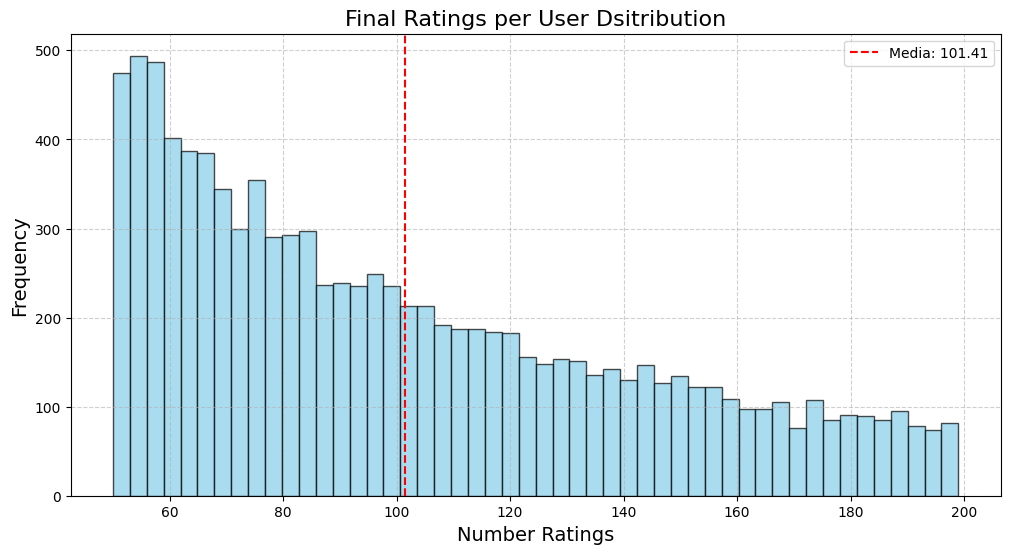

In [25]:
# Create the plot
plt.figure(figsize=(12, 6))
plt.hist(ratings_count, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Plot the mean
plt.axvline(ratings_count.mean(), color='red', linestyle='--', label=f'Media: {ratings_count.mean():.2f}')

# Add labels and title
plt.title('Final Ratings per User Dsitribution', fontsize=16)
plt.xlabel('Number Ratings', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Tras todos los filtros y el muestreo aleatorio, el dataset final tiene alrededor de **~1,000,000 ratings** distribuidos entre **10,000 usuarios**, todos con al menos 1 rating >= 4.5. La distribución del número de ratings por usuario es más uniforme y equilibrada que en el dataset original.

In [26]:
aux.rename(columns={'updatedId': 'movie_id', 'userId': 'user_id'}, inplace=True)
aux.head()

,user_id,movie_id,rating,timestamp
2461,31,25,5.0,1673768714
2462,31,23,4.0,1673768620
2463,31,70,4.5,1673768766
2464,31,176,5.0,1673768427
2465,31,287,0.5,1673843631


In [27]:
# Save the final ratings
aux.to_parquet('../data/processed/ratings_final.parquet', index=False)

In [29]:
# See the dimensions of the final ratings dataset
print(f'The final ratings dataset has {aux.shape[0]:,} ratings from {len(aux["user_id"].unique()):,} users')

The final ratings dataset has 1,014,059 ratings from 10,000 users


**Resultado:** ~1,000,000 ratings de **10,000 usuarios** sobre **5,000 películas** (todos con al menos 1 rating >= 4.5)

**Output generado:** `ml/data/processed/ratings_final.parquet`